In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from network import NetCNN1D, NetCNN2D_CSP


from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd



config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CRight'], ['CDown']]#[['CLeft'], ['CRight']]
config.session_type = 'S2'


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0
config.stride = 0.2



config.n_csp_components = 3

# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6']#['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']



model = NetCNN2D_CSP(len(config.used_classes))
model.build((32, 3, 750, 1))
model.summary()


model = NetCNN1D(len(config.used_classes))
model.build((32, 750, 3))
model.summary()



X, y = dataset_NewEEG.session_dataset(config ,'I01')





Model: "net_cnn2d_csp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 3, 108, 16)          608       
                                                                 
 sequential_1 (Sequential)   (32, 3, 22, 32)           10912     
                                                                 
 sequential_2 (Sequential)   (32, 32)                  0         
                                                                 
 sequential_3 (Sequential)   (32, 2)                   4482      
                                                                 
Total params: 16002 (62.51 KB)
Trainable params: 15906 (62.13 KB)
Non-trainable params: 96 (384.00 Byte)
_________________________________________________________________
Model: "net_cnn1d"
_________________________________________________________________
 Layer (type)                Output Shape              Pa

Training indices:  [ 1  2  3  4  5  6  8  9 10 11 12 13 14 18 19 20 21 22 23 24 25 26 27 28
 29 31 33 34 35 36]
Validation indices:  [ 0  7 15 16 17 30 32 37]
Epoch 1/500

6/6 [==============================] - 4s 144ms/step - loss: 0.6830 - acc: 0.6056 - val_loss: 0.6931 - val_acc: 0.5000
Epoch 2/500
6/6 [==============================] - 0s 31ms/step - loss: 0.6807 - acc: 0.6056 - val_loss: 0.6930 - val_acc: 0.5000
Epoch 3/500
6/6 [==============================] - 0s 32ms/step - loss: 0.6799 - acc: 0.6000 - val_loss: 0.6929 - val_acc: 0.5000
Epoch 4/500
6/6 [==============================] - 0s 32ms/step - loss: 0.6773 - acc: 0.6056 - val_loss: 0.6929 - val_acc: 0.5000
Epoch 5/500
6/6 [==============================] - 0s 37ms/step - loss: 0.6743 - acc: 0.6056 - val_loss: 0.6929 - val_acc: 0.5000
Epoch 6/500
6/6 [==============================] - 0s 33ms/step - loss: 0.6747 - acc: 0.6000 - val_loss: 0.6928 - val_acc: 0.5000
Epoch 7/500
6/6 [==============================] - 0s 32ms/

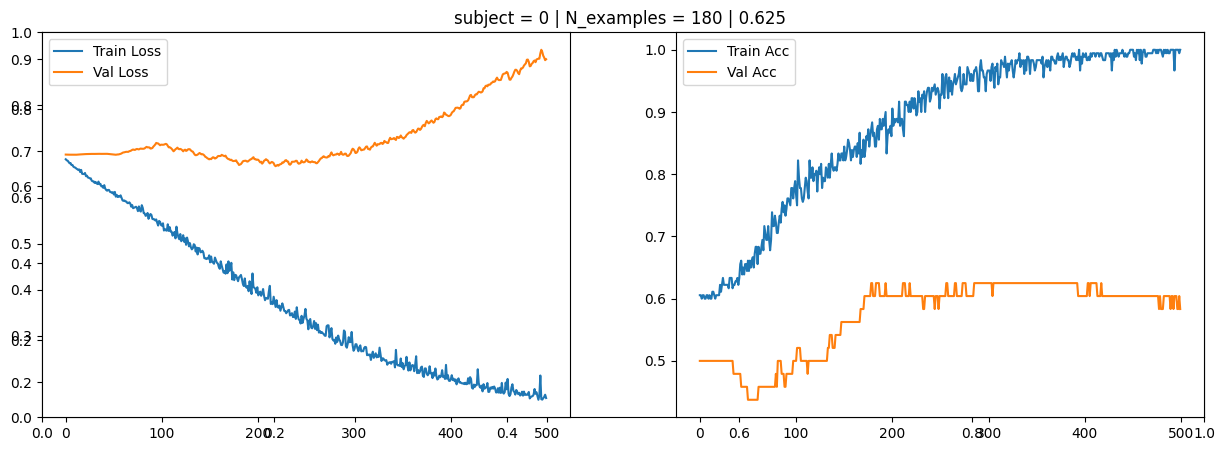

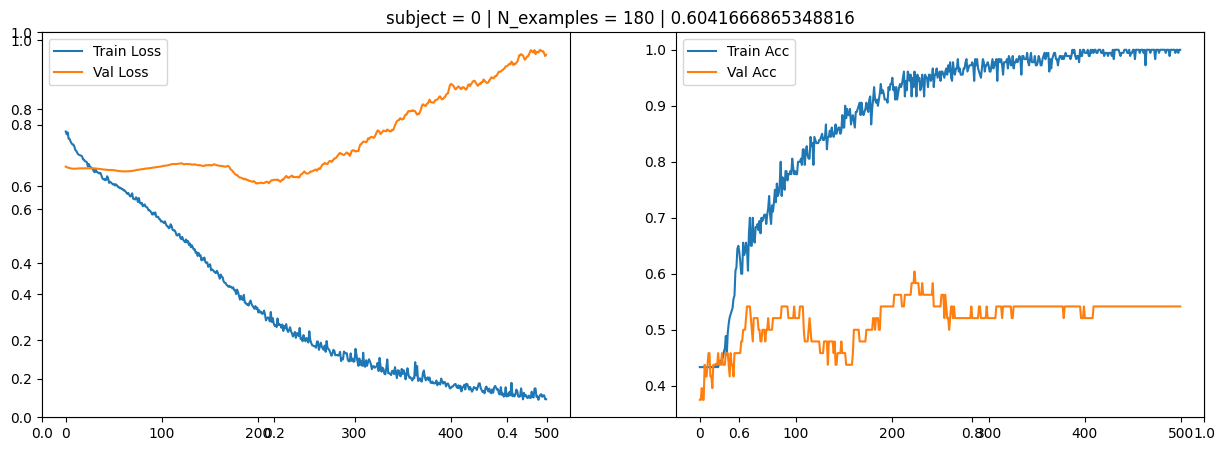

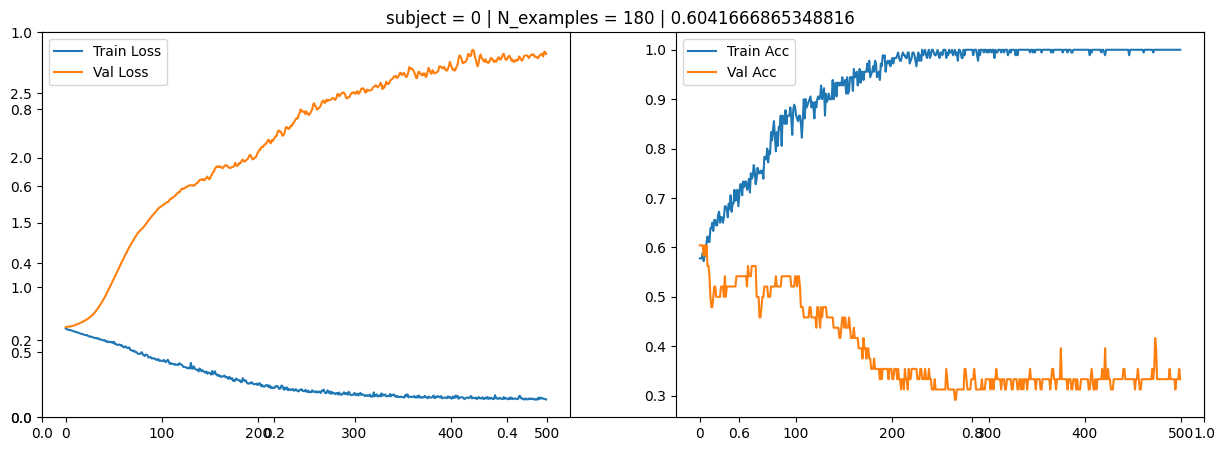

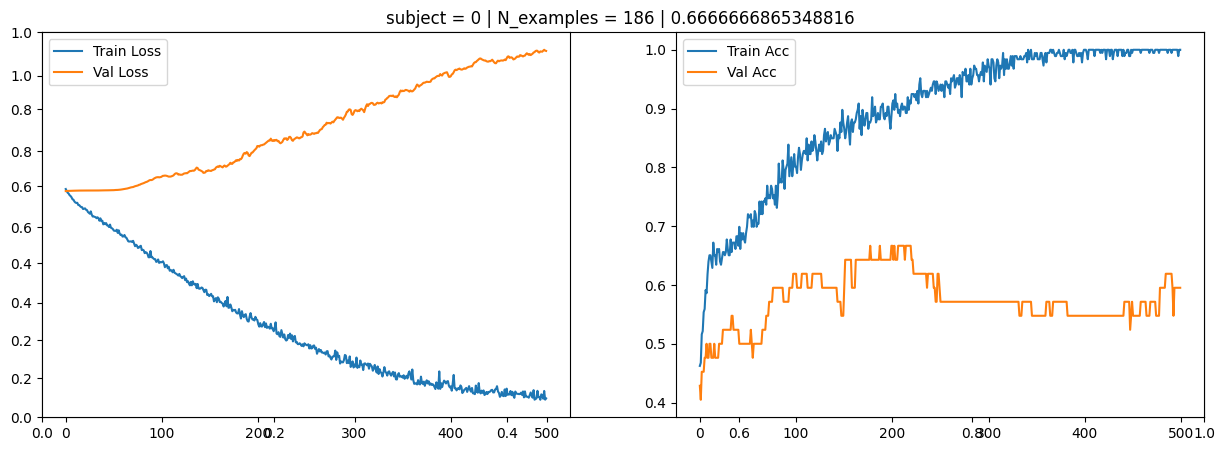

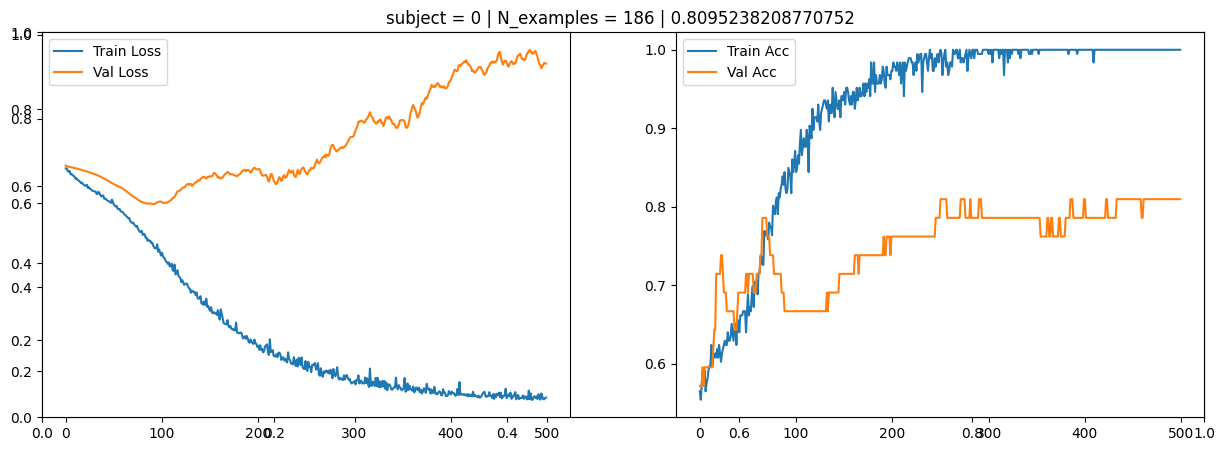

In [2]:
crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in crossValidation_KF.split(X,y):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    print("Training indices: ", train_index)
    print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    
    #X_train = np.expand_dims(X_train, 3)
    #X_valid = np.expand_dims(X_valid, 3)

    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    model = NetCNN1D(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
            optimizer=keras.optimizers.Adam(learning_rate=1e-4, weight_decay = 2e-5), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=500, batch_size=32, verbose=1)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    

print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")




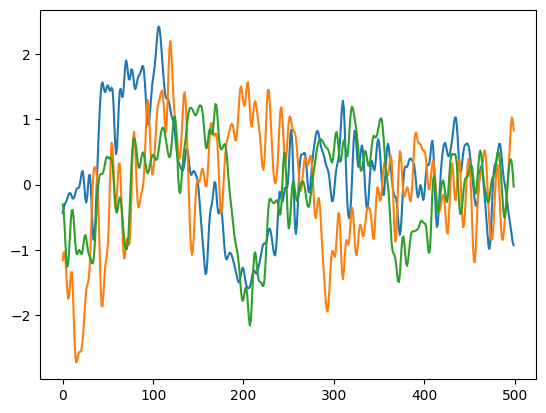

In [3]:
plt.plot(X_train[2])

In [4]:
X_train.shape

(186, 500, 3)